6 3 3 7 3 3 7 7 3

In [ ]:
import pandas as pd
import seaborn as sns
import regex as re
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from stop_words import get_stop_words
import networkx as nx
from pyvis.network import Network
import numpy as np
from sklearn.metrics import silhouette_score
from nltk.corpus import stopwords
from gensim.corpora.dictionary import Dictionary
from gensim.models.coherencemodel import CoherenceModel
from gensim.models.ldamodel import LdaModel
import pyLDAvis

import warnings

with warnings.catch_warnings():
    # silence deprecation warnings from gensimvis
    warnings.filterwarnings(action = 'ignore', category = DeprecationWarning)
    import pyLDAvis.gensim_models as gensimvis

In [6]:
df = pd.read_excel('steam reviews.xlsx')
df.head()

,Unnamed: 0,Author,Review,# of Comments,Products,Hours on Account,Remark,Users found review funny,Users found review helpful,Community Awards
0,0,Kaladin,2 10 dollar battle passes per season\n\nTitanf...,0,228 products in account,4.1 hrs on record,Not Recommended,133,3796,178
1,1,KEVE,"Now with the new battle pass system, I'm delet...",78,42 products in account,"1,865.6 hrs on record",Not Recommended,85,4370,186
2,2,⛧ M♱ropele ⛧,At least you don't have to build an apartment ...,54,655 products in account,9.6 hrs on record,Recommended,2017,3089,500
3,3,to infinity and beyond,Finally I can remove Origin.,0,Few products in account,1.1 hrs on record,Recommended,634,1770,103
4,4,chelovek bez vkusa,Finally here\n\nIt launches without Origin...\...,35,295 products in account,16.6 hrs on record,Recommended,91,2109,49


In [7]:
df = df.drop('Unnamed: 0', axis = 1, errors = 'ignore')
df.head()

,Author,Review,# of Comments,Products,Hours on Account,Remark,Users found review funny,Users found review helpful,Community Awards
0,Kaladin,2 10 dollar battle passes per season\n\nTitanf...,0,228 products in account,4.1 hrs on record,Not Recommended,133,3796,178
1,KEVE,"Now with the new battle pass system, I'm delet...",78,42 products in account,"1,865.6 hrs on record",Not Recommended,85,4370,186
2,⛧ M♱ropele ⛧,At least you don't have to build an apartment ...,54,655 products in account,9.6 hrs on record,Recommended,2017,3089,500
3,to infinity and beyond,Finally I can remove Origin.,0,Few products in account,1.1 hrs on record,Recommended,634,1770,103
4,chelovek bez vkusa,Finally here\n\nIt launches without Origin...\...,35,295 products in account,16.6 hrs on record,Recommended,91,2109,49


In [8]:
df_new = df.copy()

In [9]:
df_new['Products'] = (
    df.Products.str.replace(r'\D','', regex = True)
    .map(lambda x: 0 if x == '' else x)
    .astype(int)
)
df_new['Hours on Account'] = (
    df['Hours on Account'].str.replace(r'\D','',regex=True)
    .map(lambda x: 0 if x == '' else x)
    .astype(int)
)

df_new.head()

,Author,Review,# of Comments,Products,Hours on Account,Remark,Users found review funny,Users found review helpful,Community Awards
0,Kaladin,2 10 dollar battle passes per season\n\nTitanf...,0,228,41,Not Recommended,133,3796,178
1,KEVE,"Now with the new battle pass system, I'm delet...",78,42,18656,Not Recommended,85,4370,186
2,⛧ M♱ropele ⛧,At least you don't have to build an apartment ...,54,655,96,Recommended,2017,3089,500
3,to infinity and beyond,Finally I can remove Origin.,0,0,11,Recommended,634,1770,103
4,chelovek bez vkusa,Finally here\n\nIt launches without Origin...\...,35,295,166,Recommended,91,2109,49


In [10]:
df_new['Remark'].unique()

array(['Not Recommended', 'Recommended'], dtype=object)

In [11]:
df_new['Remark'] = df_new.Remark.map({'Not Recommended':0,'Recommended':1})
df_new = df_new.rename({'Remark':'isRecommended'}, axis = 1)
df_new

,Author,Review,# of Comments,Products,Hours on Account,isRecommended,Users found review funny,Users found review helpful,Community Awards
0,Kaladin,2 10 dollar battle passes per season\n\nTitanf...,0,228,41,0,133,3796,178
1,KEVE,"Now with the new battle pass system, I'm delet...",78,42,18656,0,85,4370,186
2,⛧ M♱ropele ⛧,At least you don't have to build an apartment ...,54,655,96,1,2017,3089,500
3,to infinity and beyond,Finally I can remove Origin.,0,0,11,1,634,1770,103
4,chelovek bez vkusa,Finally here\n\nIt launches without Origin...\...,35,295,166,1,91,2109,49
...,...,...,...,...,...,...,...,...,...
995,Mayano Top Gun,GAME NGENTOD,0,74,8195,0,1,14,0
996,Dubinn,"Used to love it, now look at what they did to ...",0,347,1057,0,0,11,0
997,Fiery,You removed linux support? AI cheats basically...,0,0,18,0,0,24,0
998,ZenTrix,You accidentally fall off a cliff while trying...,0,162,3316,1,0,7,1


In [12]:
df_new.describe()

,# of Comments,Products,Hours on Account,isRecommended,Users found review funny,Users found review helpful,Community Awards
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,4.170000,238.503000,8478.611000,0.558000,50.336000,209.777000,17.629000
std,16.599537,844.863574,16197.627037,0.496873,135.558457,400.198041,42.173332
min,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,644.500000,0.000000,2.000000,25.000000,1.000000
50%,0.000000,45.000000,3609.500000,1.000000,10.000000,79.000000,5.000000
75%,3.000000,205.000000,10376.250000,1.000000,45.250000,233.500000,16.000000
max,434.000000,16131.000000,241730.000000,1.000000,2017.000000,6142.000000,517.000000


<Axes: >

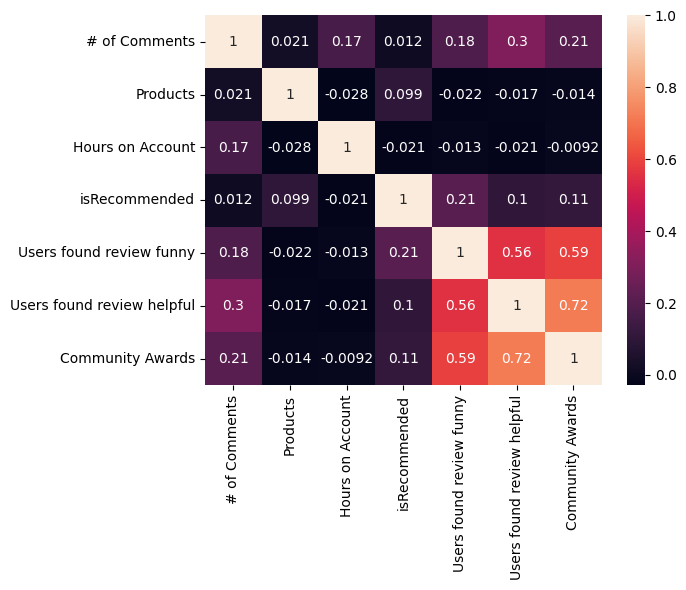

In [13]:
sns.heatmap(df_new.corr(numeric_only=True), annot = True)

# Wordcloud

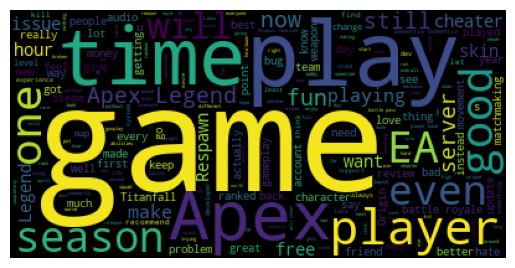

In [14]:
all_reviews = ' '.join(df_new['Review'].str.replace('\n',' ').tolist())

wordcloud = WordCloud().generate_from_text(all_reviews)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [15]:
# Function to make generation easier
def generate_wordcloud(text: str, min_word_length: int = 0) -> None:
    wordcloud = WordCloud(min_word_length=min_word_length).generate_from_text(text)
    plt.imshow(wordcloud)
    plt.axis('off')
    plt.show()
    return

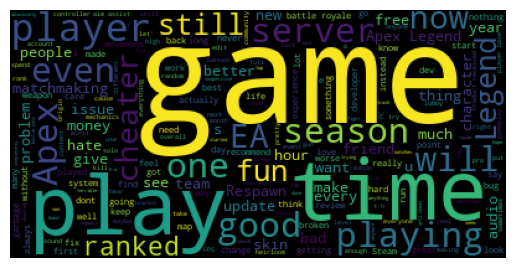

In [16]:
high_hour_reviews = ' '.join(
    df_new[df_new['Hours on Account'] > df_new['Hours on Account'].mean()]['Review']
    .str.replace('\n', ' ').tolist()
    )

generate_wordcloud(high_hour_reviews)

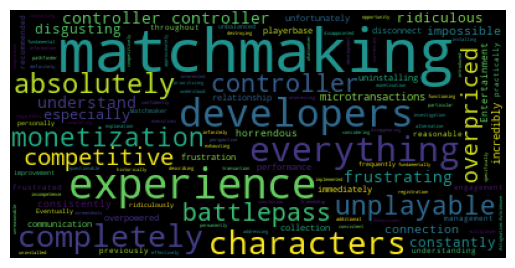

In [17]:
negative_reviews = ' '.join(
    df_new[df_new['isRecommended'] == 0]['Review']
    .str.replace('\n',' ').tolist()
)

# Changing the min_word_length argument filters out some of the common words
generate_wordcloud(negative_reviews, 10)

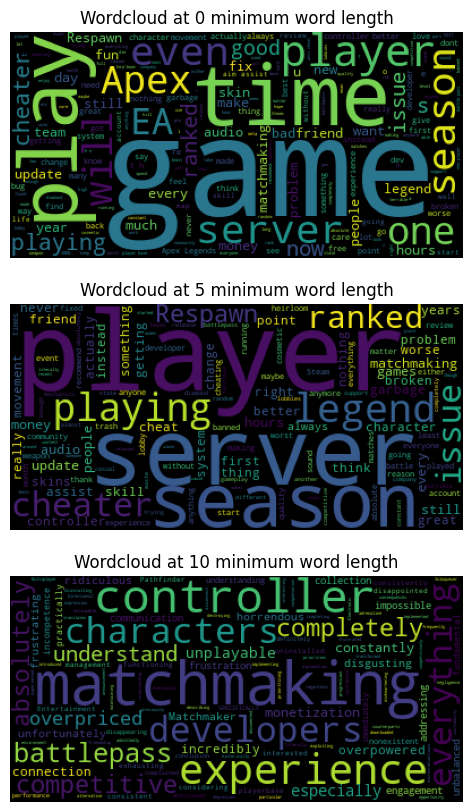

In [18]:
# Generate wordcloud plots in intervals of 5 from 0 to 10
high_hour_negative_reviews = ' '.join(
    df_new[(df_new['Hours on Account'] > df_new['Hours on Account'].mean()) & (df_new['isRecommended'] == 0)]['Review']
    .str.replace('\n',' ').tolist()
)
fig, axs = plt.subplots(3, 1, figsize = (12,10))

for i,v in enumerate([0, 5, 10]):
    wordcloud = WordCloud(min_word_length = v).generate_from_text(high_hour_negative_reviews)
    axs[i].imshow(wordcloud)
    axs[i].set_axis_off()
    axs[i].set_title(f'Wordcloud at {v} minimum word length')

In [19]:
def generate_all_wordclouds(texts: str, start: int = 0, end: int = 10, step: int = 5, 
                            figsize: tuple[int,int] = (15,12)) -> None:
    num_plots = (end - start)//step + 1
    intervals = [i for i in range(start, end + 1, step)]    
    fig, axs = plt.subplots(num_plots, 1, figsize = figsize)
    
    for i,v in enumerate(intervals):
        wordcloud = WordCloud(min_word_length = v).generate_from_text(texts)
        axs[i].imshow(wordcloud)
        axs[i].set_axis_off()
        axs[i].set_title(f'Wordcloud at {v} minimum word length')
        
    return

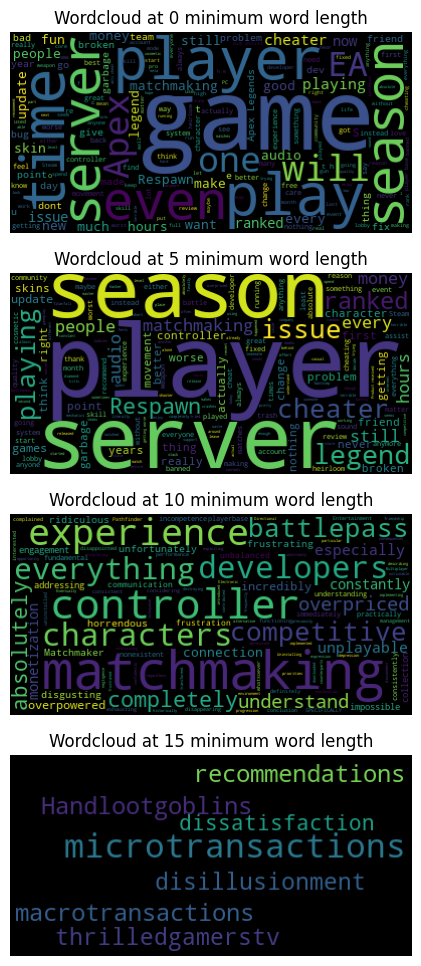

In [20]:
generate_all_wordclouds(high_hour_negative_reviews, end = 15)

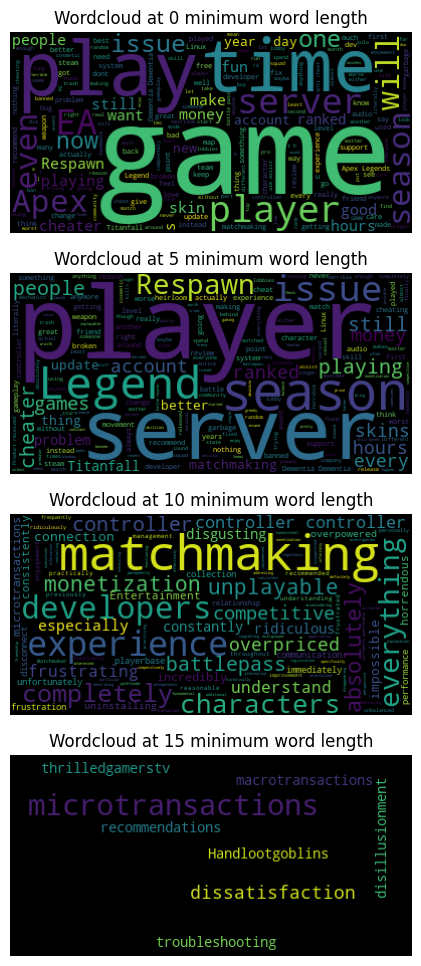

In [21]:
generate_all_wordclouds(negative_reviews, end = 15)

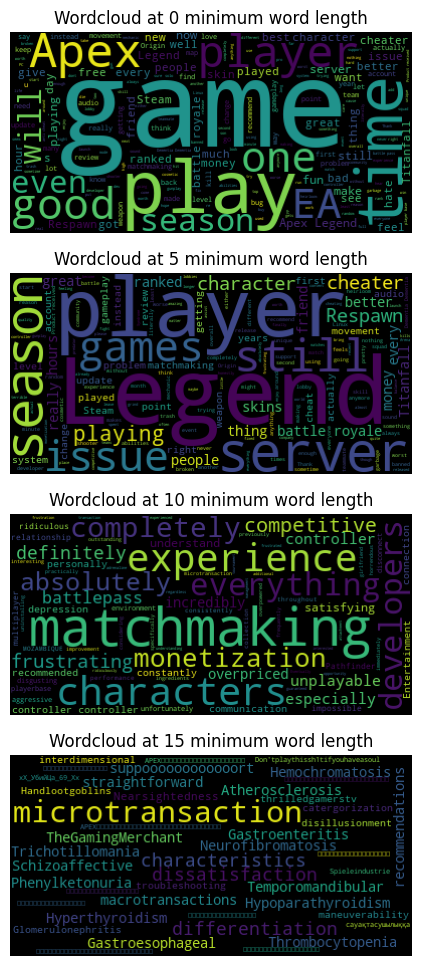

In [22]:
generate_all_wordclouds(all_reviews, end = 15)

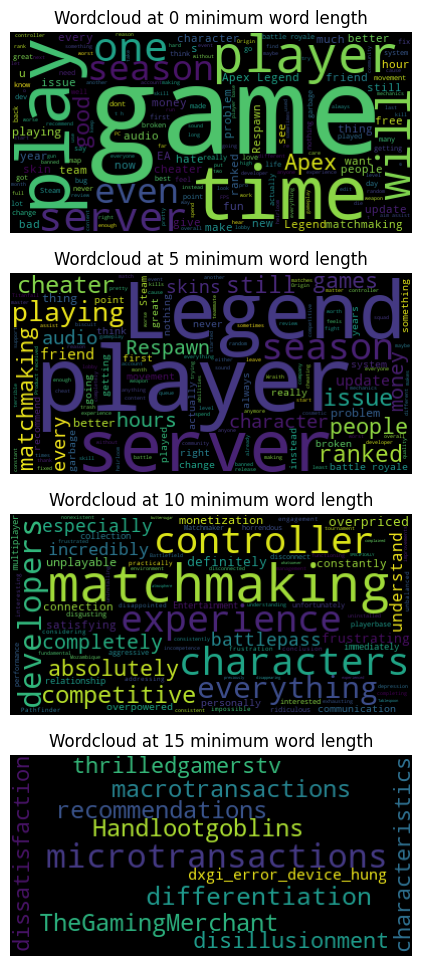

In [23]:
generate_all_wordclouds(high_hour_reviews, end = 15)

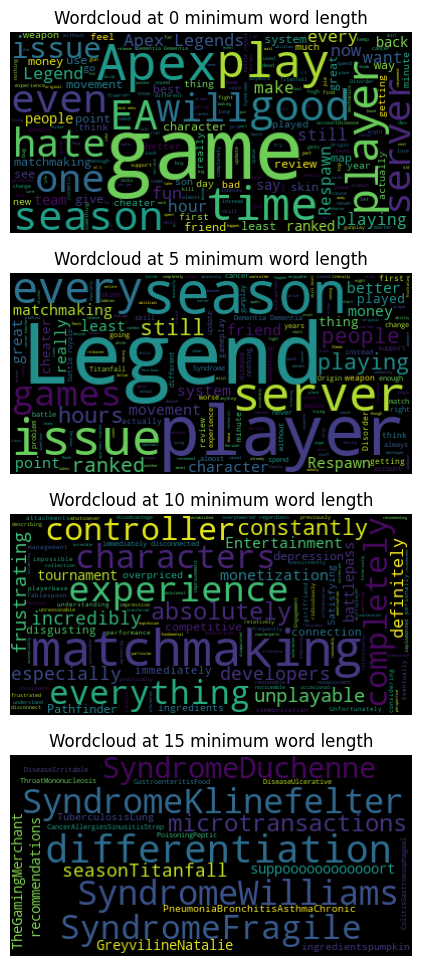

In [24]:
# Filter by helpful
helpful_df = df_new[df_new['Users found review helpful'] > df_new['Users found review helpful'].mean()]

helpful = ' '.join(helpful_df['Review'].str.replace('\n','').tolist())

generate_all_wordclouds(helpful, end = 15)

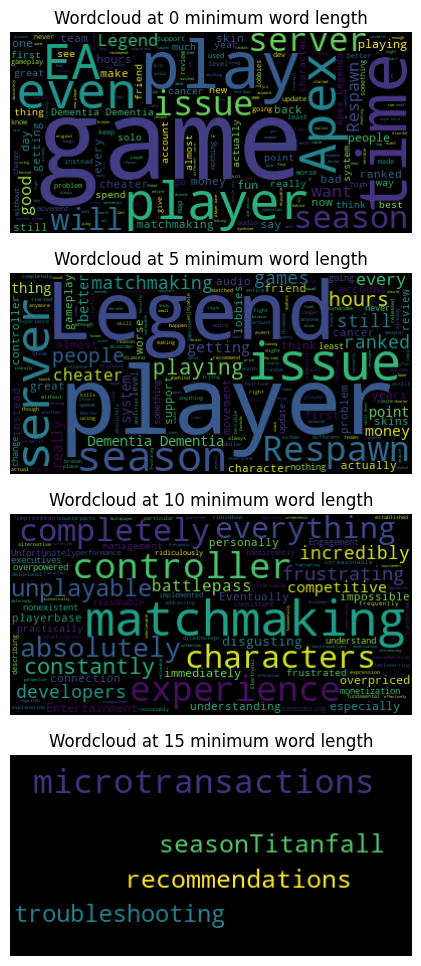

In [25]:
helpful_negative = ' '.join(helpful_df[helpful_df['isRecommended'] == 0]['Review'].str.replace('\n','').tolist())

generate_all_wordclouds(helpful_negative, end = 15)

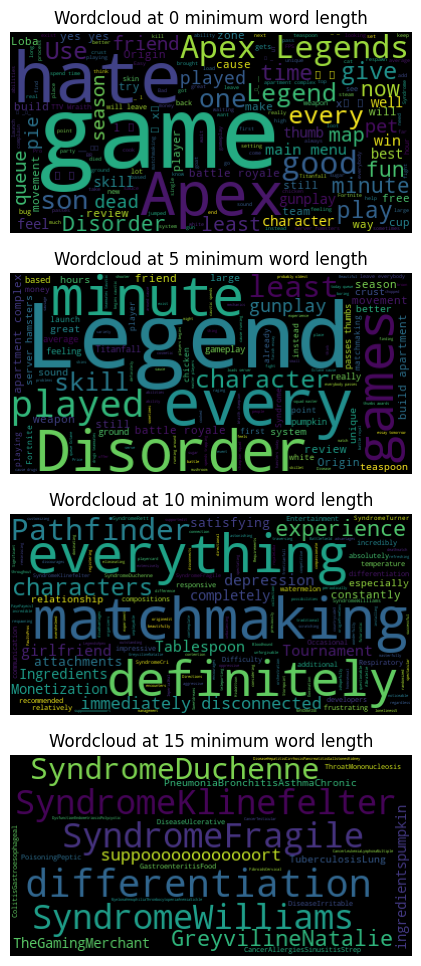

In [26]:
helpful_positive = ' '.join(helpful_df[helpful_df['isRecommended'] == 1]['Review'].str.replace('\n','').tolist())

generate_all_wordclouds(helpful_positive, end = 15)

# Topic Extraction

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

In [28]:
documents = df_new['Review'].str.replace('\n','').tolist()

tfid = TfidfVectorizer(stop_words = 'english')
document_X = tfid.fit_transform(documents)

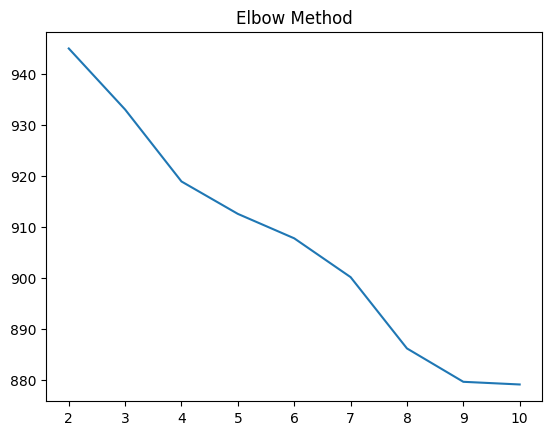

In [29]:
inertias = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters = k, random_state = 0, n_init = 10)
    model = kmeans.fit(document_X)
    inertias.append(model.inertia_)
    
plt.plot(range(2,11), inertias)
plt.title('Elbow Method')
plt.show()

In [30]:
kmeans = KMeans(n_clusters = 4, random_state = 0, n_init = 10)
model = kmeans.fit(document_X)

In [31]:
features = tfid.get_feature_names_out()
features

array(['00', '000', '000art', ..., '𝙪𝙨𝙚𝙙', '𝙬𝙖𝙮', '𝙬𝙞𝙩𝙝'],
      shape=(7842,), dtype=object)

In [32]:
model.cluster_centers_[0].argsort()[::-1]

array([3901, 2190, 3865, ...,   20,   19,   53], shape=(7842,))

In [33]:
features[1438]

'complex'

In [34]:
for i in range(4):
    print(f'Topic {i}')
    tfid_vector = model.cluster_centers_[i].argsort()[::-1]
    top_words = [features[vector] for vector in tfid_vector][:100]
    print(top_words)

Topic 0
['loba', 'ea', 'linux', 'product', 'received', 'better', 'legends', 'sex', 'origin', 'game', 'fortnite', '10', 'review', 'good', 'pet', 'thumbs', 'apex', 'cat', 'xノ', '__', 'steam', 'like', 'ape', 'ass', 'leave', '二つ', 'best', '_ヽ_', 'mozambique', 'servers', 'games', 'support', 'battle', 'play', 'just', 'gets', 'want', 'royale', 'passes', 'duos', 'finally', 'removed', 'bring', 'everybody', 'got', 'add', 'apesex', 'yes', 'trash', 'awards', 'don', 'cheat', 'arenas', 'banned', 'fix', 'time', 'kill', 'bad', 'party', 'gibby', 'friends', 'br', 'matchmaking', 'gay', 'respawn', 'hours', 'fun', 'anti', 'remove', 'recommend', 'cheaters', 'day', 'line', 'use', 'aim', 'assist', 'say', 'balls', 'make', 'deck', 'bruda', 'gender', 'neutral', 'trust', 'read', 'doesn', 'need', 'legend', 'players', 'pass', 'christs', 'problem', 'anymore', 'hard', 'right', 'free', 'asked', 'pathfinder', 'uninstall', 'big']
Topic 1
['win', 'complex', 'apartment', 'build', 'don', 'apex', 'architect', 'need', 'fun',

In [35]:
stop_words = (get_stop_words('en') 
              + # Adding additional stop words to avoid inconsistency user warning
              ['ain', 'daren', 'hadn', 'herse', 'himse', 'itse', 'mayn', 'mightn', 'mon', 'mustn', 'myse', 'needn', 'oughtn', 'shan', 'vis'])

In [36]:
def extract_topics(text_col: pd.Series, getModel: bool = False, stop_words: list[str] = stop_words) -> KMeans:
    document = text_col.str.replace('\n',' ').str.replace(r'[^a-zA-Z\s0-9]','', regex = True).tolist()
    
    print('==='*12, end = '\n\n')
    print('Initializing Model...\n')
    tfid = TfidfVectorizer(stop_words = stop_words)
    X = tfid.fit_transform(document)
    vocab = tfid.get_feature_names_out()
    
    print('==='*12, end = '\n\n')
    print('Inertia Graph for Optimal Cluster Selection\n')
    inertias = []
    for k in range(2, 11):
        kmeans = KMeans(n_clusters = k, random_state = 0, n_init = 10)
        model = kmeans.fit(X)
        inertias.append(model.inertia_)
        
    plt.plot(range(2,11), inertias)
    plt.title('Elbow Method')
    plt.show()
    
    print('Graph Plotted. Please Analyze and Choose a cluster number based on graph.\n')
    k = input('Specify number of clusters for model: ')
    
    while not k.isnumeric():
        k = input('Specify number of clusters for model: ')
    
    k = int(k)
    
    print('==='*12, end = '\n\n')
    print('Creating Model...\n')
    kmeans = KMeans(n_clusters = k, random_state = 0, n_init = 10)
    model = kmeans.fit(X)
    
    print('==='*12, end = '\n\n')
    print('Extracted Topics: \n')
    features = tfid.get_feature_names_out()
    for i in range(k):
        print(f'Topic {i}')
        tfid_vector = model.cluster_centers_[i].argsort()[::-1]
        top_words = [features[vector] for vector in tfid_vector][:100]
        print(top_words)
    print('==='*12)
    
    return model, X, vocab if getModel else None


Initializing Model...


Inertia Graph for Optimal Cluster Selection



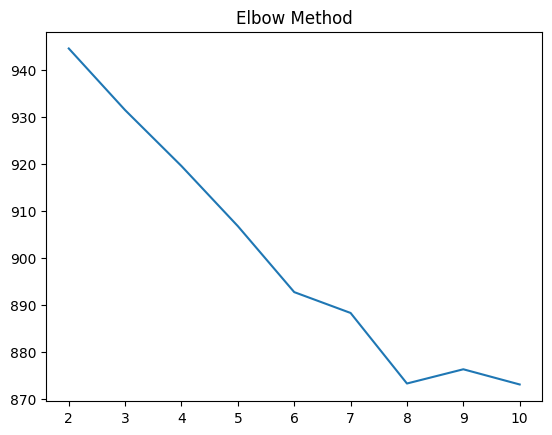

Graph Plotted. Please Analyze and Choose a cluster number based on graph.


Creating Model...


Extracted Topics: 

Topic 0
['win', 'apartment', 'build', 'complex', 'apex', 'architect', 'fun', 'octane', 'legend', '10000', 'zens', '000', 'zips', 'zampella', 'zaidi', 'yucky', 'yr', 'youwant', 'youtube', 'yonder', 'yolk', 'yoinked', 'yogurt', 'yo', 'yesyesyeyesyes', 'yesyesyesyesyes', 'yesyesyesyes', 'zombify', 'yesterday', 'yenye', 'yellow', 'yelling', 'yell', 'yeast', 'yearat', 'yeahthey', 'yeahit', 'yeahh', 'yeah', 'yay', 'yards', 'yanked', 'yank', 'yall', 'yaguya', 'ya', 'xx69xx', 'xeroderma', 'xd', 'xbox', 'wtf', 'wrote', 'wrong', 'written', 'writing', 'write', 'wretches', 'wraiths', 'wraithnaruto', 'wraith', 'wow', 'wound', 'wouldve', 'worthy', 'worthwhile', 'worth', 'worstrun', 'worst', 'worshipers', 'worsereworked', 'worsend', 'worsen', 'worse', 'worry', 'worried', 'worlds', 'worldreal', 'worldbuilding', 'word', 'woowoo', 'wooooow', 'woohoo', 'wooden', 'wood', 'wonders', 'wonderla

(KMeans(n_clusters=6, n_init=10, random_state=0),
 <Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 24561 stored elements and shape (1000, 6985)>,
 None)

In [37]:
extract_topics(df_new['Review']) # Optimal Input 6

In [38]:
positive_highs= df_new[
 (df_new['isRecommended'] == 1) &
 (df_new['Hours on Account'] > df_new['Hours on Account'].mean()) &
 (df_new['Users found review helpful'] > df_new['Users found review helpful'].mean())
].copy()

positive_lows = df_new[
 (df_new['isRecommended'] == 1) &
 (df_new['Hours on Account'] < df_new['Hours on Account'].mean()) &
 (df_new['Users found review helpful'] > df_new['Users found review helpful'].mean())
].copy()

negative_highs = df_new[
 (df_new['isRecommended'] == 0) &
 (df_new['Hours on Account'] > df_new['Hours on Account'].mean()) &
 (df_new['Users found review helpful'] > df_new['Users found review helpful'].mean())
].copy()

negative_lows = df_new[
 (df_new['isRecommended'] == 0) &
 (df_new['Hours on Account'] < df_new['Hours on Account'].mean()) &
 (df_new['Users found review helpful'] > df_new['Users found review helpful'].mean())
].copy()

all_positive = df_new[df_new['isRecommended'] == 1].copy()
all_negative = df_new[df_new['isRecommended'] == 0].copy()


Initializing Model...


Inertia Graph for Optimal Cluster Selection



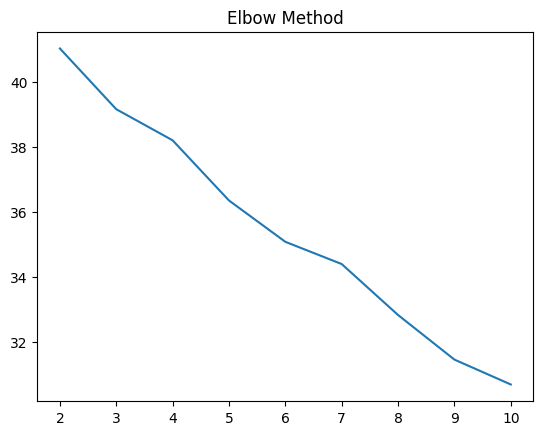

Graph Plotted. Please Analyze and Choose a cluster number based on graph.


Creating Model...


Extracted Topics: 

Topic 0
['legends', 'apex', 'fortnite', 'loba', 'gay', 'read', 'played', 'life', 'win', 'yesyesyesyesyes', 'step', 'friends', 'valkyrie', 'game', 'cute', 'wattson', 'hard', 'fun', 'battle', 'absolutely', 'changed', 'girlfriend', 'pretty', 'weewee', 'deserve', 'ea', 'royale', 'sexually', 'pathfinder', 'attracted', 'raging', 'likes', '45', 'thumbs', 'yesyesyesyes', 'players', 'play', 'father', 'games', 'feel', 'ut', 'playing', 'depressionand', 'depression', 'abilities', 'movement', 'matchmaking', 'gunplay', 'sleep', 'asap', 'healthy', '000', 'price', 'relationship', 'decent', 'schedule', 'breakdown', 'disorder', 'anxiety', 'erections', 'swings', 'racism', 'mood', 'bipolar', 'relationships', 'character', 'day', 'fastpaced', 'restart', 'recommend', 'origins', 'data', 'change', 'gamertag', 'yesyesyeyesyes', 'team', 'skill', 'playstyle', 'unique', 'mechanics', 'lot', 'time', 's

(KMeans(n_clusters=3, n_init=10, random_state=0),
 <Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 897 stored elements and shape (46, 665)>,
 None)

In [39]:
extract_topics(positive_highs['Review']) # Optimal Input 3


Initializing Model...


Inertia Graph for Optimal Cluster Selection



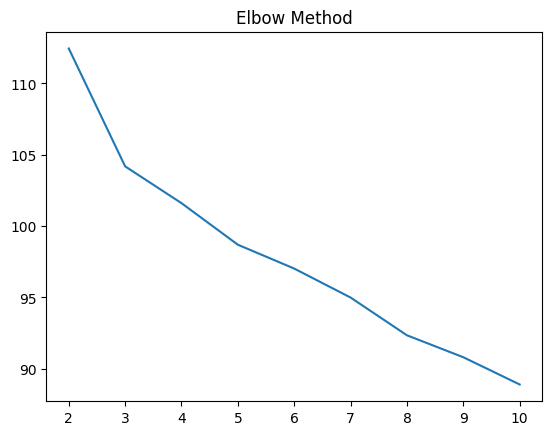

Graph Plotted. Please Analyze and Choose a cluster number based on graph.


Creating Model...


Extracted Topics: 

Topic 0
['pet', 'thumbs', 'cat', 'leave', 'passes', 'awards', 'friends', 'pass', 'rampart', 'passing', 'capybara', 'beautiful', 'steam', '1999', 'zip', '175', '15ounce', '15', '1440p', '14', '13', '12ounce', '121', '12', '11easy', '11', '10inch', '1010', '1000', '02s', 'womans', 'wolfhirschhorn', 'wolffparkinsonwhite', 'wisses', 'wise', 'wisdom', 'wire', 'wipes', 'wiped', 'wine', 'win', 'wilson', 'williams', 'willebrand', 'wife', 'wielded', 'wide', 'white', 'whiskey', 'whipped', 'wheel', 'wet', 'wellsmart', 'wegeners', 'week', 'wedges', 'weave', 'weapons', 'weapon', 'wattsons', 'wattson', 'watson', 'watermelon', 'water', 'watching', 'watch', 'warzone', 'warranted', 'wanna', 'walls', 'waiting', 'wait', 'vortex', 'von', 'voice', 'vodka', 'vocal', 'visuals', 'visual', 'virus', 'virgins', 'videos', 'vices', 'vestibular', 'vertigo', 'veins', 'vein', 'vegetable', 'vast', 'varie

(KMeans(n_clusters=3, n_init=10, random_state=0),
 <Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 2737 stored elements and shape (133, 1702)>,
 None)

In [40]:
extract_topics(positive_lows['Review']) # Optimal Input 3


Initializing Model...


Inertia Graph for Optimal Cluster Selection



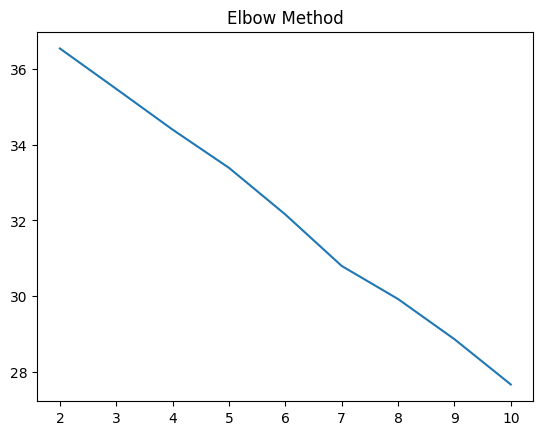

Graph Plotted. Please Analyze and Choose a cluster number based on graph.


Creating Model...


Extracted Topics: 

Topic 0
['trash', 'leaving', 'bad', 'review', 'server', 'servers', 'bruda', 'gender', 'gibbys', 'neutral', 'white', 'methbender', 'walter', 'gunplay', 'recommend', 'legends', 'game', 'banned', 'balancing', 'monetization', 'movement', 'hard', 'stuff', 'terrible', 'abilities', 'hours', 'fun', 'players', 'ea', 'games', 'fake', 'suicidal', '1k', 'lazy', '15', 'flaming', 'inconsistent', 'unbalanced', 'asf', 'znce', 'mess', 'product', 'promises', 'deserves', 'expensive', 'mechanics', '2500', 'cronus', 'god', 'solved', 'respawns', 'xbox', 'versions', 'stick', 'galore', 'stacks', 'regs', 'ttk', 'poverty', 'teamates', 'p2020s', 'cons', 'developers', 'maps', 'overpowered', '1600', 'useless', 'alot', 'grab', 'latency', 'moves', 'cosmetics', 'played', 'pros', 'guns', 'tick', 'basically', 'friends', 'start', 'horrible', 'leave', 'main', 'match', 'bugs', 'assist', 'pass', 'respawn', 'd

(KMeans(n_clusters=7, n_init=10, random_state=0),
 <Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 2467 stored elements and shape (41, 1527)>,
 None)

In [41]:
extract_topics(negative_highs['Review']) # Optimal Input 7


Initializing Model...


Inertia Graph for Optimal Cluster Selection



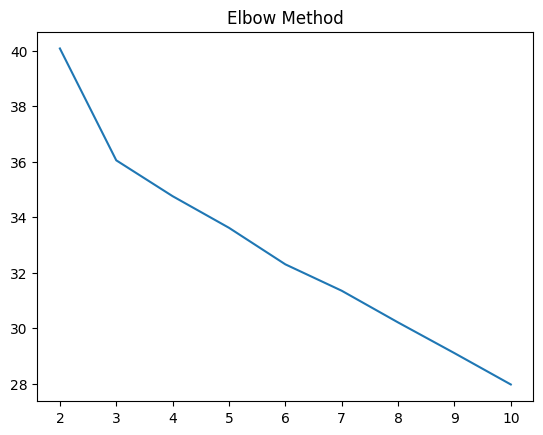

Graph Plotted. Please Analyze and Choose a cluster number based on graph.


Creating Model...


Extracted Topics: 

Topic 0
['game', 'apex', 'play', 'ea', 'season', 'servers', 'playing', 'trash', 'skins', 'players', 'respawn', 'legends', 'issues', 'matchmaking', 'people', 'bikini', 'fun', 'unplayable', 'bad', 'hours', 'time', 'update', 'review', 'money', 'day', 'level', 'games', 'account', 'crashing', 'tournament', 'streamer', 'support', 'decided', 'steam', 'read', 'dementia', 'lobbies', 'spend', 'started', 'hit', 'literally', 'pls', 'china', 'lock', 'region', 'snort', 'cocaine', 'skill', 'love', 'session', 'diamond', 'cheaters', 'issue', 'match', 'gameplay', 'crashed', 'gaming', 'devs', 'player', 'freezes', 'removed', 'played', 'ranked', 'cancer', 'supposed', 'fine', 'addicting', 'unhealthiest', 'communities', 'involved', 'legend', 'pass', 'completely', 'pc', 'gain', 'sad', 'predators', 'friends', 'minute', 'petty', 'penalty', 'abandon', 'heirloom', 'based', '100x', 'weapon', 'solo', 

(KMeans(n_clusters=3, n_init=10, random_state=0),
 <Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 2297 stored elements and shape (48, 1581)>,
 None)

In [42]:
extract_topics(negative_lows['Review']) # Optimal nput 3


Initializing Model...


Inertia Graph for Optimal Cluster Selection



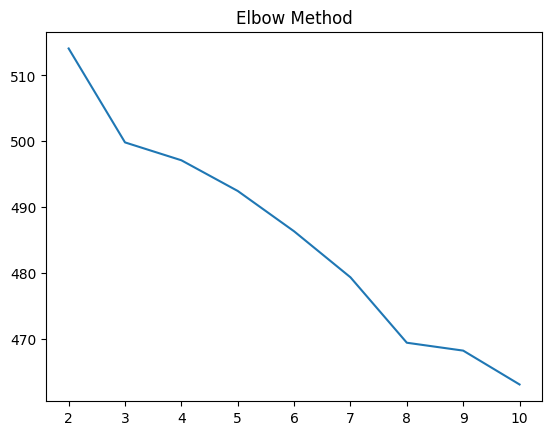

Graph Plotted. Please Analyze and Choose a cluster number based on graph.


Creating Model...


Extracted Topics: 

Topic 0
['win', 'apartment', 'complex', 'build', 'apex', 'architect', 'fun', 'octane', 'legend', 'zika', 'zest', 'zampella', 'zaidi', 'yucky', 'youtube', 'yonder', 'yolk', '11easy', '15ounce', '1510', '150', '15', '1440p', '14', '13inch', '1300', '13', '12ounce', '12k', '12673517612345', '1250', '121', 'yo', 'xbox', 'wrote', 'wrong', 'writing', 'wraiths', 'wraith', 'worthwhile', 'worth', 'worstrun', 'worst', 'worse', 'worry', 'worlds', 'worldbuilding', 'word', 'woowoo', 'wooooow', 'woohoo', 'wooden', 'wondering', 'wonderfully', 'wonderful', 'womans', 'wolfhirschhorn', 'wolffparkinsonwhite', 'wisses', 'wishing', 'wise', 'wisdom', 'wire', 'wiping', 'wipes', 'wiped', 'wipe', 'wins', 'winninggetting', 'winning', 'winner', 'wink', 'wingman', 'wine', 'window', 'wilson', 'williams', 'willebrand', 'wild', 'wife', 'wielded', 'widespread', 'wide', 'white', 'whiskey', 'whisked', 'wh

(KMeans(n_clusters=3, n_init=10, random_state=0),
 <Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 10420 stored elements and shape (558, 4030)>,
 None)

In [43]:
extract_topics(all_positive['Review']) # Optimal Input 3


Initializing Model...


Inertia Graph for Optimal Cluster Selection



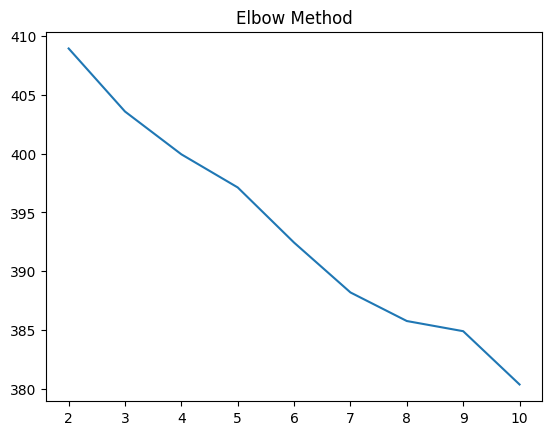

Graph Plotted. Please Analyze and Choose a cluster number based on graph.


Creating Model...


Extracted Topics: 

Topic 0
['gibbys', 'gender', 'bruda', 'neutral', 'christs', 'removed', '11', 'zens', 'yr', 'youwant', 'youtube', 'yoinked', 'yesterdays', 'yesterday', 'yellow', 'yeast', 'yearat', 'yeahthey', 'yeahh', 'yeah', 'yards', 'zombify', 'yall', 'ya', 'xd', 'xbox', 'wtf', 'wrote', 'wrong', 'written', 'writing', 'write', 'wretches', 'wraiths', 'wraithnaruto', 'wraith', 'wow', 'wound', 'wouldve', 'worthy', 'worthwhile', 'worth', 'worst', 'worshipers', 'worsereworked', 'worsend', 'worsen', 'worse', 'worry', 'worried', 'worlds', 'worldreal', 'word', 'wood', 'wonders', 'wonderland', 'wondering', 'wonderful', 'wondered', 'woman', 'wl', 'witness', 'withthats', 'witcher', 'wishes', 'wished', 'wise', 'wiping', 'wipe', 'wins', 'winrate', 'wingman', 'windows', 'win', 'willnotimplementsolos', 'wild', 'wifi', 'wife', 'wielding', 'widespread', 'wide', 'whopping', 'whooping', 'white', 'whisper',

(KMeans(n_clusters=7, n_init=10, random_state=0),
 <Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 14141 stored elements and shape (442, 4772)>,
 None)

In [44]:
extract_topics(all_negative['Review']) # Optimal Input 7

# Visualization

In [45]:
box_df = df_new[['Hours on Account','isRecommended']].copy()
box_df['isRecommended'] = box_df['isRecommended'].map({0:'Not Recommended',1:'Recommended'})
box_df

,Hours on Account,isRecommended
0,41,Not Recommended
1,18656,Not Recommended
2,96,Recommended
3,11,Recommended
4,166,Recommended
...,...,...
995,8195,Not Recommended
996,1057,Not Recommended
997,18,Not Recommended
998,3316,Recommended


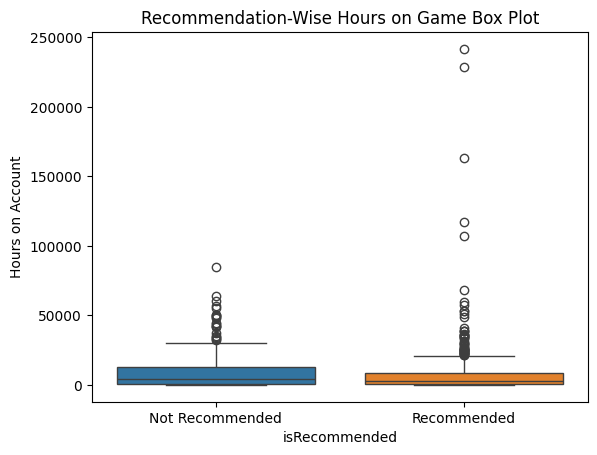

In [46]:
sns.boxplot(data = box_df, x = 'isRecommended', y = 'Hours on Account', hue = 'isRecommended')
plt.title('Recommendation-Wise Hours on Game Box Plot')
plt.show()

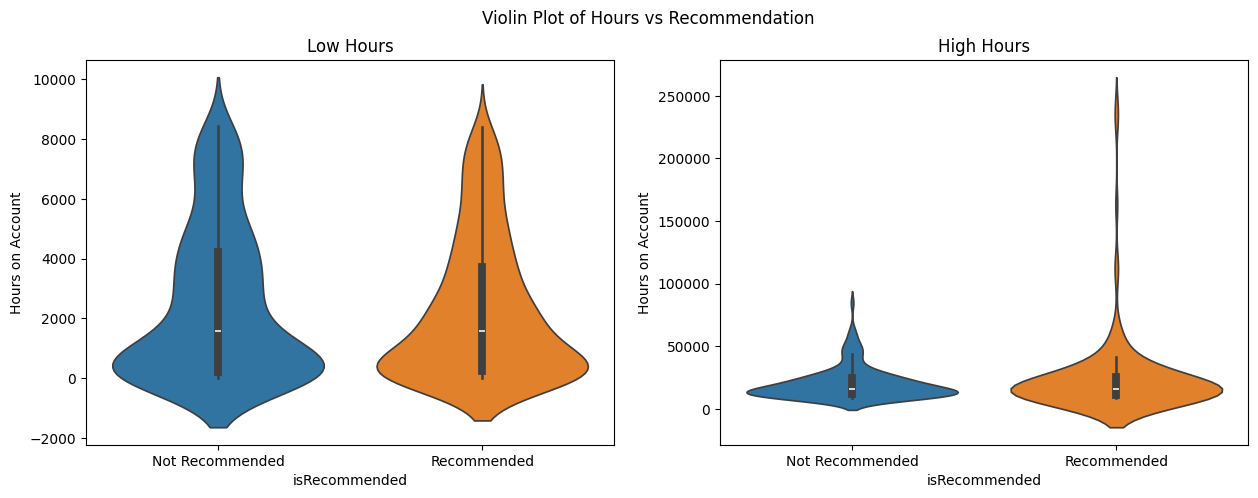

In [47]:
high_hours_df = box_df[box_df['Hours on Account'] > box_df['Hours on Account'].mean()].copy()
low_hours_df = box_df[box_df['Hours on Account'] <= box_df['Hours on Account'].mean()].copy()

fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (15,5))

fig.suptitle('Violin Plot of Hours vs Recommendation')

sns.violinplot(low_hours_df[['Hours on Account','isRecommended']], x = 'isRecommended', y = 'Hours on Account', hue = 'isRecommended', ax = axs[0])
axs[0].set_title('Low Hours')

sns.violinplot(high_hours_df[['Hours on Account','isRecommended']], x = 'isRecommended', y = 'Hours on Account', hue = 'isRecommended', ax = axs[1])
axs[1].set_title('High Hours')

plt.show()

# I wanna see if the hours on the game affects whether the player would recommend it or not?

# Violin plot
# Left: Low Hours
# Right: High Hours

In [48]:
box_df

,Hours on Account,isRecommended
0,41,Not Recommended
1,18656,Not Recommended
2,96,Recommended
3,11,Recommended
4,166,Recommended
...,...,...
995,8195,Not Recommended
996,1057,Not Recommended
997,18,Not Recommended
998,3316,Recommended


In [49]:
box_df['Hours on Account'].describe()

count      1000.000000
mean       8478.611000
std       16197.627037
min           1.000000
25%         644.500000
50%        3609.500000
75%       10376.250000
max      241730.000000
Name: Hours on Account, dtype: float64

<Axes: >

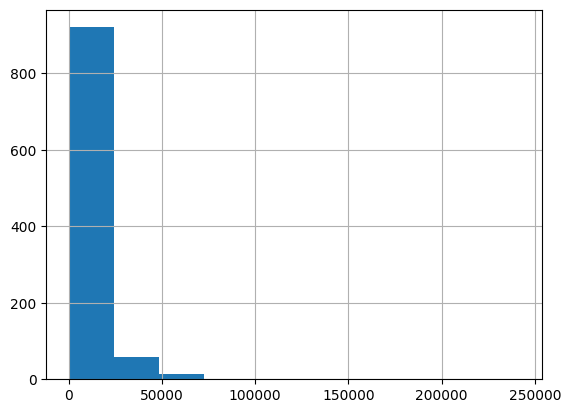

In [50]:
box_df['Hours on Account'].hist()

In [51]:
df_new.head()

,Author,Review,# of Comments,Products,Hours on Account,isRecommended,Users found review funny,Users found review helpful,Community Awards
0,Kaladin,2 10 dollar battle passes per season\n\nTitanf...,0,228,41,0,133,3796,178
1,KEVE,"Now with the new battle pass system, I'm delet...",78,42,18656,0,85,4370,186
2,⛧ M♱ropele ⛧,At least you don't have to build an apartment ...,54,655,96,1,2017,3089,500
3,to infinity and beyond,Finally I can remove Origin.,0,0,11,1,634,1770,103
4,chelovek bez vkusa,Finally here\n\nIt launches without Origin...\...,35,295,166,1,91,2109,49


In [52]:
numeric_df = df_new.select_dtypes(exclude = 'object')
column_order = [col for col in numeric_df.columns if col != 'isRecommended'] + ['isRecommended']
numeric_df = numeric_df[column_order]
numeric_df['isRecommended'] = numeric_df['isRecommended'].map({0:'Not Recommended',1:'Recommended'})
numeric_df

,# of Comments,Products,Hours on Account,Users found review funny,Users found review helpful,Community Awards,isRecommended
0,0,228,41,133,3796,178,Not Recommended
1,78,42,18656,85,4370,186,Not Recommended
2,54,655,96,2017,3089,500,Recommended
3,0,0,11,634,1770,103,Recommended
4,35,295,166,91,2109,49,Recommended
...,...,...,...,...,...,...,...
995,0,74,8195,1,14,0,Not Recommended
996,0,347,1057,0,11,0,Not Recommended
997,0,0,18,0,24,0,Not Recommended
998,0,162,3316,0,7,1,Recommended


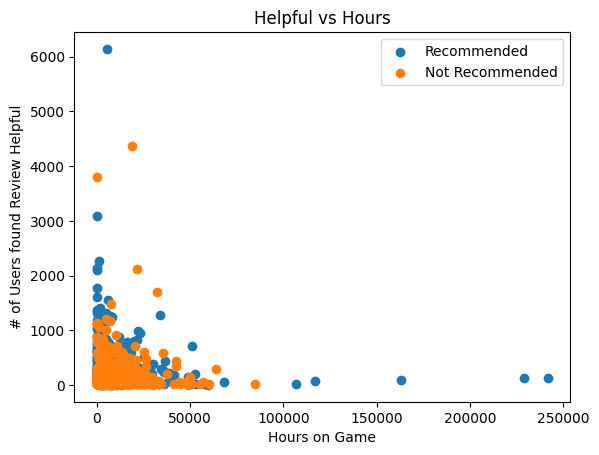

In [53]:
fig, ax = plt.subplots()

ax.scatter(
    data = numeric_df[numeric_df['isRecommended'] == 'Recommended'],
    y = 'Users found review helpful', 
    x = 'Hours on Account',
    label = 'Recommended'
)

ax.scatter(
    data = numeric_df[numeric_df['isRecommended'] == 'Not Recommended'],
    y = 'Users found review helpful', 
    x = 'Hours on Account',
    label = 'Not Recommended'
)

ax.set_title('Helpful vs Hours')
ax.set_ylabel('# of Users found Review Helpful')
ax.set_xlabel('Hours on Game')

plt.legend()
plt.show()

In [54]:
numeric_df[numeric_df['isRecommended'] == 'Not Recommended']['Hours on Account'].apply(np.log)

0      3.713572
1      9.833923
7      9.966368
8      8.961751
9      9.773550
         ...   
994    7.966933
995    9.011279
996    6.963190
997    2.890372
999    3.135494
Name: Hours on Account, Length: 442, dtype: float64

In [55]:
numeric_df[numeric_df['isRecommended'] == 'Not Recommended'][['Users found review helpful','Hours on Account']].apply(np.log)

,Users found review helpful,Hours on Account
0,8.241703,3.713572
1,8.382518,9.833923
7,7.659171,9.966368
8,7.304516,8.961751
9,6.184149,9.773550
...,...,...
994,1.945910,7.966933
995,2.639057,9.011279
996,2.397895,6.963190
997,3.178054,2.890372


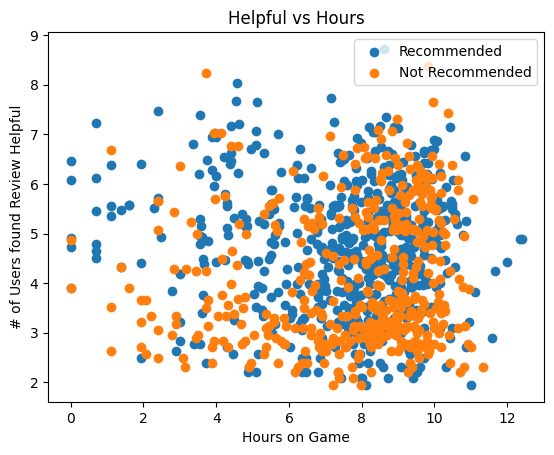

In [56]:
fig, ax = plt.subplots()

ax.scatter(
    data = numeric_df[numeric_df['isRecommended'] == 'Recommended'][['Users found review helpful','Hours on Account']].apply(np.log),
    y = 'Users found review helpful',
    x = 'Hours on Account',
    label = 'Recommended'
)

ax.scatter(
    data = numeric_df[numeric_df['isRecommended'] == 'Not Recommended'][['Users found review helpful','Hours on Account']].apply(np.log),
    y = 'Users found review helpful',
    x = 'Hours on Account',
    label = 'Not Recommended'
)

ax.set_title('Helpful vs Hours')
ax.set_ylabel('# of Users found Review Helpful')
ax.set_xlabel('Hours on Game')

plt.legend()
plt.show()

In [57]:
numeric_df[['Products', 'Hours on Account']].apply(np.log1p)

,Products,Hours on Account
0,5.433722,3.737670
1,3.761200,9.833977
2,6.486161,4.574711
3,0.000000,2.484907
4,5.690359,5.117994
...,...,...
995,4.317488,9.011402
996,5.852202,6.964136
997,0.000000,2.944439
998,5.093750,8.106816


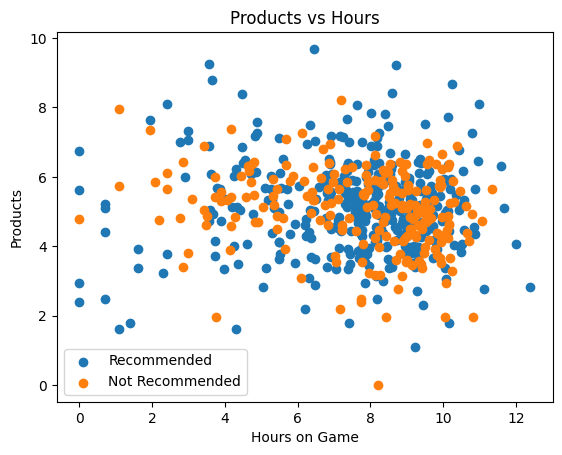

In [58]:
fig, ax = plt.subplots()

ax.scatter(
    data = numeric_df[numeric_df['isRecommended'] == 'Recommended'][['Products', 'Hours on Account']].apply(np.log),
    y = 'Products', 
    x = 'Hours on Account',
    label = 'Recommended'
)

ax.scatter(
    data = numeric_df[numeric_df['isRecommended'] == 'Not Recommended'][['Products', 'Hours on Account']].apply(np.log),
    y = 'Products', 
    x = 'Hours on Account',
    label = 'Not Recommended'
)

ax.set_title('Products vs Hours')
ax.set_ylabel('Products')
ax.set_xlabel('Hours on Game')

plt.legend()
plt.show()

### Categorizing Reviews

In [59]:
df_new.head()

,Author,Review,# of Comments,Products,Hours on Account,isRecommended,Users found review funny,Users found review helpful,Community Awards
0,Kaladin,2 10 dollar battle passes per season\n\nTitanf...,0,228,41,0,133,3796,178
1,KEVE,"Now with the new battle pass system, I'm delet...",78,42,18656,0,85,4370,186
2,⛧ M♱ropele ⛧,At least you don't have to build an apartment ...,54,655,96,1,2017,3089,500
3,to infinity and beyond,Finally I can remove Origin.,0,0,11,1,634,1770,103
4,chelovek bez vkusa,Finally here\n\nIt launches without Origin...\...,35,295,166,1,91,2109,49


# KMeans


Initializing Model...


Inertia Graph for Optimal Cluster Selection



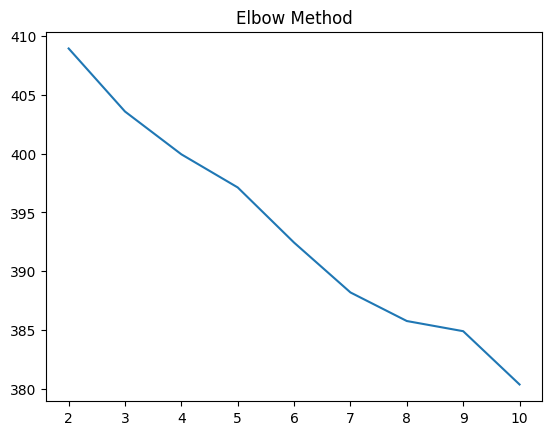

Graph Plotted. Please Analyze and Choose a cluster number based on graph.


Creating Model...


Extracted Topics: 

Topic 0
['gibbys', 'gender', 'bruda', 'neutral', 'christs', 'removed', '11', 'zens', 'yr', 'youwant', 'youtube', 'yoinked', 'yesterdays', 'yesterday', 'yellow', 'yeast', 'yearat', 'yeahthey', 'yeahh', 'yeah', 'yards', 'zombify', 'yall', 'ya', 'xd', 'xbox', 'wtf', 'wrote', 'wrong', 'written', 'writing', 'write', 'wretches', 'wraiths', 'wraithnaruto', 'wraith', 'wow', 'wound', 'wouldve', 'worthy', 'worthwhile', 'worth', 'worst', 'worshipers', 'worsereworked', 'worsend', 'worsen', 'worse', 'worry', 'worried', 'worlds', 'worldreal', 'word', 'wood', 'wonders', 'wonderland', 'wondering', 'wonderful', 'wondered', 'woman', 'wl', 'witness', 'withthats', 'witcher', 'wishes', 'wished', 'wise', 'wiping', 'wipe', 'wins', 'winrate', 'wingman', 'windows', 'win', 'willnotimplementsolos', 'wild', 'wifi', 'wife', 'wielding', 'widespread', 'wide', 'whopping', 'whooping', 'white', 'whisper',

In [60]:
negative_model, negative_document_X, negative_vocab = extract_topics(all_negative['Review'], getModel = True)

In [61]:
negative_topics = {
    0: "Streaming from Social Platforms",
    1: "Removed Gamemodes",
    2: "Titanfall is better",
    3: "OS support",
    4: "Microtransactions and Payment",
    5: "Server Issues",
    6: "Bad Matchmaking"
}

In [62]:
all_negative['Category'] = negative_model.predict(negative_document_X)
all_negative['Category'] = all_negative['Category'].map(negative_topics)
all_negative

,Author,Review,# of Comments,Products,Hours on Account,isRecommended,Users found review funny,Users found review helpful,Community Awards,Category
0,Kaladin,2 10 dollar battle passes per season\n\nTitanf...,0,228,41,0,133,3796,178,Titanfall is better
1,KEVE,"Now with the new battle pass system, I'm delet...",78,42,18656,0,85,4370,186,Server Issues
7,🐾Gizmo🐾,We don't have a cheater problem.\nOk we do hav...,48,508,21298,0,85,2120,211,OS support
8,Blödhgarm,"I've got nearly 3k hours in this game, most of...",0,0,7799,0,28,1487,247,Server Issues
9,DeeDee MegaDooDoo,"I've been playing this game since release, and...",16,0,17563,0,21,485,59,Server Issues
...,...,...,...,...,...,...,...,...,...,...
994,TTV Tarquar_,♥♥♥♥ GAME NEEDS A SOLO MODE. ALL MY TEAMATES A...,3,25,2884,0,1,7,0,Server Issues
995,Mayano Top Gun,GAME NGENTOD,0,74,8195,0,1,14,0,Server Issues
996,Dubinn,"Used to love it, now look at what they did to ...",0,347,1057,0,0,11,0,Bad Matchmaking
997,Fiery,You removed linux support? AI cheats basically...,0,0,18,0,0,24,0,OS support


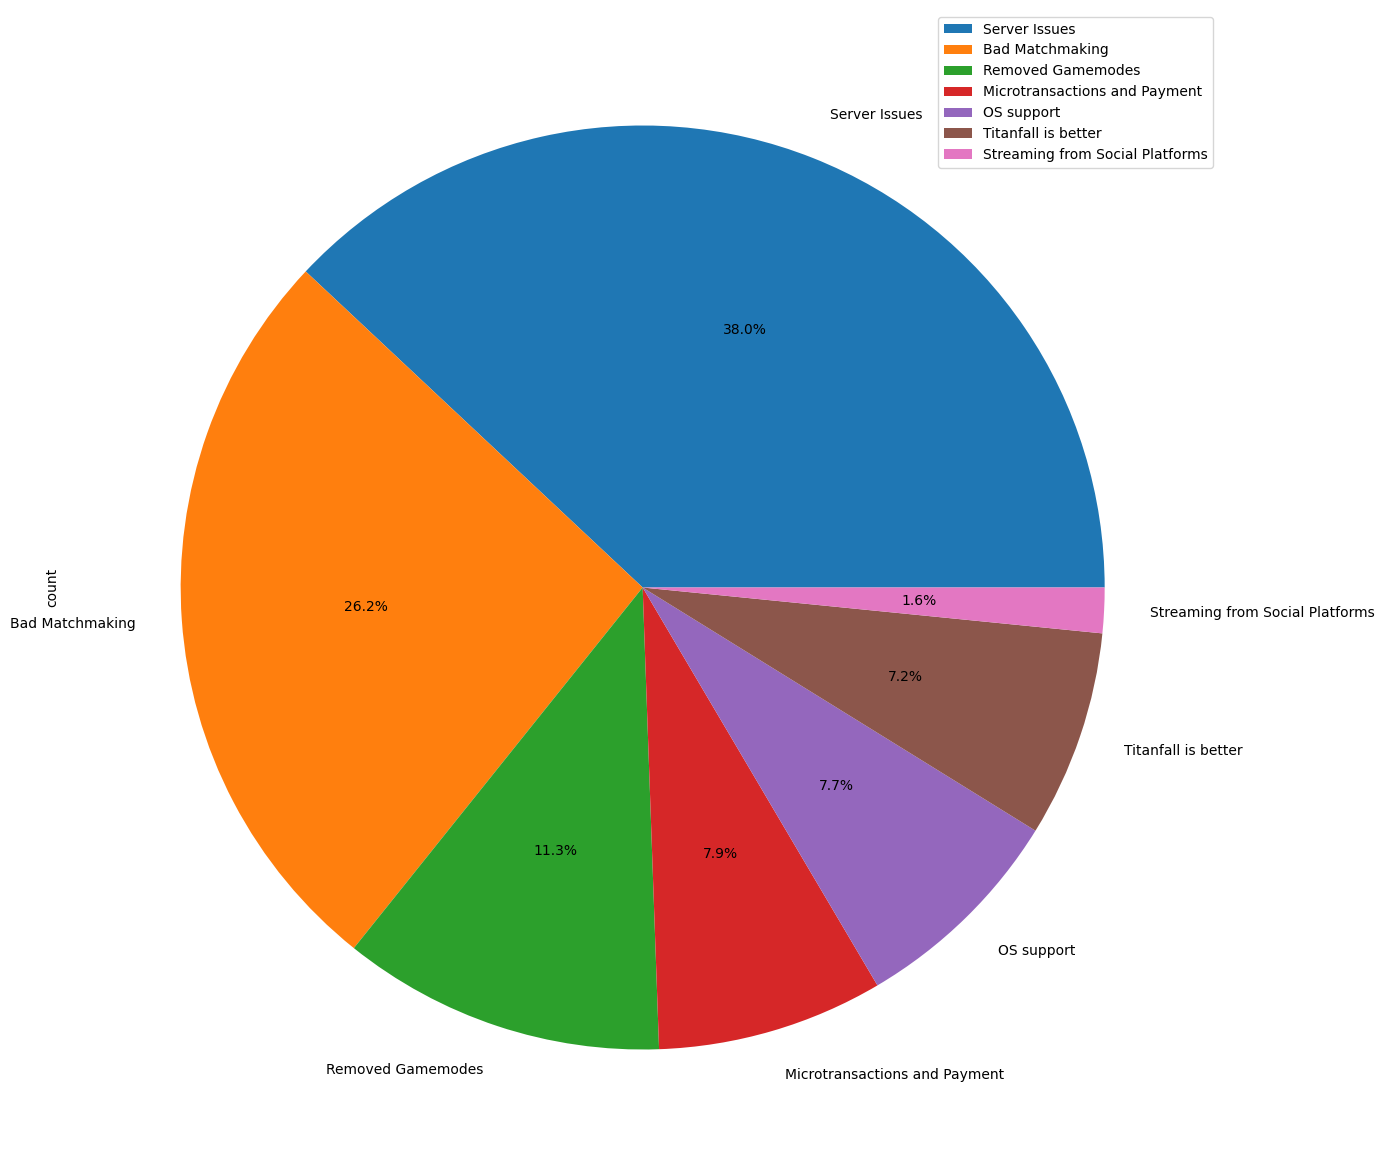

In [63]:
(
    all_negative['Category']
    .value_counts()
    .reset_index()
    .set_index('Category')
    .plot(
            kind = 'pie',
            y = 'count',
            figsize = (15, 15),
            autopct = '%.1f%%'
        )
)
plt.legend(loc = 'upper right')
plt.show()


Initializing Model...


Inertia Graph for Optimal Cluster Selection



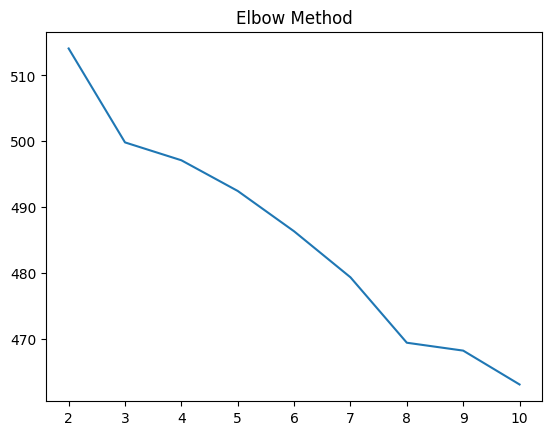

Graph Plotted. Please Analyze and Choose a cluster number based on graph.


Creating Model...


Extracted Topics: 

Topic 0
['win', 'apartment', 'complex', 'build', 'apex', 'architect', 'fun', 'octane', 'legend', 'zika', 'zest', 'zampella', 'zaidi', 'yucky', 'youtube', 'yonder', 'yolk', '11easy', '15ounce', '1510', '150', '15', '1440p', '14', '13inch', '1300', '13', '12ounce', '12k', '12673517612345', '1250', '121', 'yo', 'xbox', 'wrote', 'wrong', 'writing', 'wraiths', 'wraith', 'worthwhile', 'worth', 'worstrun', 'worst', 'worse', 'worry', 'worlds', 'worldbuilding', 'word', 'woowoo', 'wooooow', 'woohoo', 'wooden', 'wondering', 'wonderfully', 'wonderful', 'womans', 'wolfhirschhorn', 'wolffparkinsonwhite', 'wisses', 'wishing', 'wise', 'wisdom', 'wire', 'wiping', 'wipes', 'wiped', 'wipe', 'wins', 'winninggetting', 'winning', 'winner', 'wink', 'wingman', 'wine', 'window', 'wilson', 'williams', 'willebrand', 'wild', 'wife', 'wielded', 'widespread', 'wide', 'white', 'whiskey', 'whisked', 'wh

In [64]:
positive_model, positive_document_X, positive_vocab = extract_topics(all_positive['Review'], getModel = True) # Optimal Input 3

In [65]:
positive_topics = {
    0: 'Unlike Fortnite',
    1: 'Emotes and Friends',
    2: 'Removal of Origin Launcher'
}

In [66]:
all_positive['Category'] = positive_model.predict(positive_document_X)
all_positive['Category'] = all_positive['Category'].map(positive_topics)
all_positive

,Author,Review,# of Comments,Products,Hours on Account,isRecommended,Users found review funny,Users found review helpful,Community Awards,Category
2,⛧ M♱ropele ⛧,At least you don't have to build an apartment ...,54,655,96,1,2017,3089,500,Unlike Fortnite
3,to infinity and beyond,Finally I can remove Origin.,0,0,11,1,634,1770,103,Removal of Origin Launcher
4,chelovek bez vkusa,Finally here\n\nIt launches without Origin...\...,35,295,166,1,91,2109,49,Removal of Origin Launcher
5,Shanks,uninstall origin,0,0,161,1,281,1180,64,Removal of Origin Launcher
6,azure,doesnt launch with origin\n\nedit: easy anti-c...,117,195,5460,1,915,6142,355,Removal of Origin Launcher
...,...,...,...,...,...,...,...,...,...,...
978,L a s w i n k a,"I will leave the cat here, so that everybody w...",0,81,4183,1,4,71,11,Emotes and Friends
979,Rest.N.Pieces,Product received for free\n\nits super duper f...,0,0,8417,1,4,29,3,Removal of Origin Launcher
985,Dayonica,"Buff Loba pls))0 (Posted 20 July, 2021.)\n\nIT...",0,85,25933,1,5,22,1,Removal of Origin Launcher
990,Sonder,"I had an entire family, went through a divorce...",1,562,5345,1,10,10,3,Removal of Origin Launcher


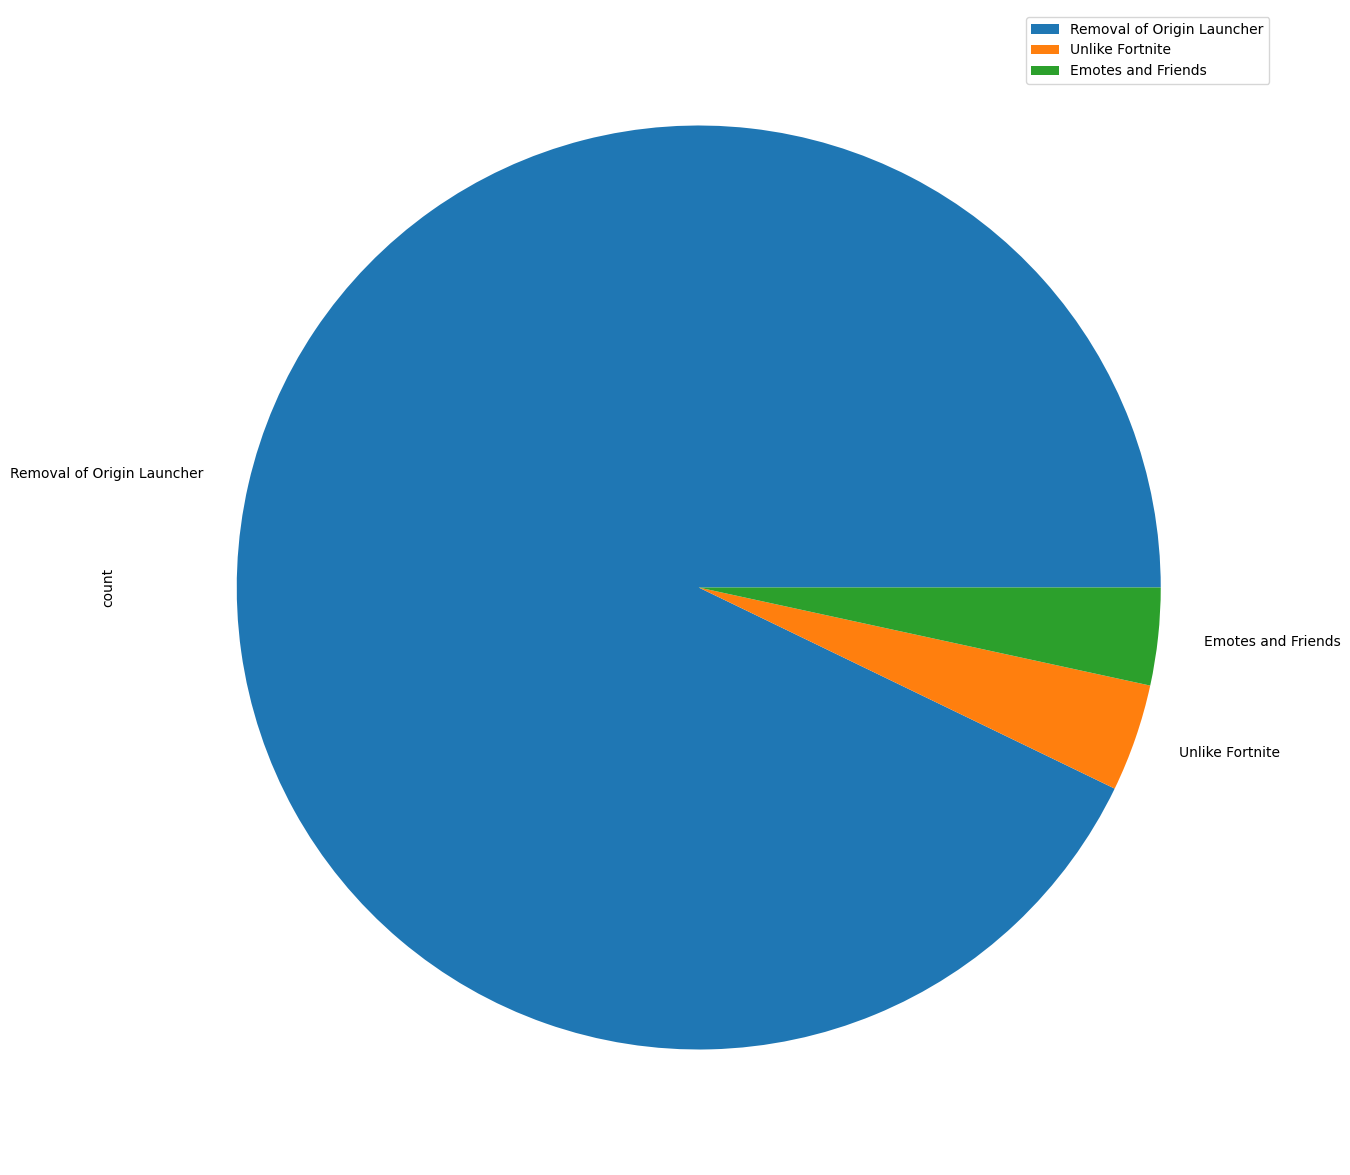

In [67]:
(
    all_positive['Category']
    .value_counts()
    .reset_index()
    .set_index('Category')
    .plot(
            kind = 'pie',
            y = 'count',
            figsize = (15, 15)
        )
)
plt.legend(loc = 'upper right')
plt.show()

In [68]:
silhouette_negative = silhouette_score(negative_document_X, negative_model.predict(negative_document_X))

silhouette_positive = silhouette_score(positive_document_X, positive_model.predict(positive_document_X))

print('Silhouette Score for Negative Review Topics: {}'.format(silhouette_negative))
print('Silhouette Score for Positive Review Topics: {}'.format(silhouette_positive))

Silhouette Score for Negative Review Topics: 0.04568509111139485
Silhouette Score for Positive Review Topics: 0.05350337684485115


# LDA

In [69]:
# Download stopwords from nltk only once
# import nltk

# nltk.download('stopwords')

In [70]:
def tokenize(text: str) -> list[str]:
    # Clean text by removing non-alphanumeric characters
    text = re.sub('[^a-zA-Z0-9 ]', '', text)
    
    # Split words into non-stopword lowercase words
    texts = [word for word in text.lower().split() if word not in stopwords.words('english')]

    return texts
    

In [83]:
def get_gensim_reqs(doc_list: list[str]) -> tuple[list,dict,list]:
    """
    Get the required variables for the LDA model initalization

    Args:
        doc_list (list[str]): Document list that contains all the documents to be processed in string format within a python list

    Returns:
        tuple[list,dict,list]: Processed documents, dictionary, and corpus for LDA model
    """
    
    # Get initial documents
    gensim_docs = [tokenize(doc) for doc in doc_list]
    gensim_dict = Dictionary(gensim_docs)
    
    # Activate lazy loading
    if len(gensim_dict.id2token) == 0:
        _ = gensim_dict[0]
        
    # Process into corpus
    gensim_corpus = [gensim_dict.doc2bow(texts) for texts in gensim_docs]
    
    return gensim_docs, gensim_dict, gensim_corpus

In [89]:
negative_gensim_docs, negative_dictionary, negative_gensim_corpus = get_gensim_reqs(all_negative['Review'].tolist())
negative_lda = LdaModel(negative_gensim_corpus, num_topics = 5, id2word = negative_dictionary.id2token)

In [90]:
negative_gensim_corpus[0]

[(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1)]

In [91]:
negative_lda.print_topics()

[(0,
  '0.032*"game" + 0.007*"play" + 0.006*"apex" + 0.005*"even" + 0.005*"like" + 0.005*"ea" + 0.005*"dont" + 0.005*"players" + 0.004*"time" + 0.004*"legends"'),
 (1,
  '0.021*"game" + 0.006*"players" + 0.006*"apex" + 0.006*"get" + 0.005*"play" + 0.005*"like" + 0.005*"dont" + 0.005*"still" + 0.004*"time" + 0.004*"playing"'),
 (2,
  '0.021*"game" + 0.007*"play" + 0.006*"apex" + 0.006*"dont" + 0.005*"even" + 0.005*"get" + 0.005*"ea" + 0.004*"playing" + 0.004*"players" + 0.004*"servers"'),
 (3,
  '0.030*"game" + 0.007*"get" + 0.007*"players" + 0.006*"time" + 0.006*"apex" + 0.005*"season" + 0.005*"dont" + 0.005*"play" + 0.004*"like" + 0.004*"want"'),
 (4,
  '0.027*"game" + 0.008*"play" + 0.007*"even" + 0.007*"time" + 0.006*"apex" + 0.005*"like" + 0.005*"people" + 0.005*"players" + 0.005*"fix" + 0.005*"playing"')]

In [92]:
negative_coherence = CoherenceModel(
    model = negative_lda,
    texts = negative_gensim_docs,
    corpus = negative_gensim_corpus,
    dictionary = negative_dictionary
)

In [93]:
negative_coherence.get_coherence()

np.float64(0.42908530681463264)

In [ ]:
def get_optimal_lda(corpus: list[tuple[int,int]], dictionary: Dictionary, docs: list[list[str]], coherence_method: str = 'c_v', start: int = 1, end: int = 10) -> tuple[int,float]:
    # Variables to store coherence for plot
    coherences = []
    optimal_topics = (-1, -1)
    optimal_model = None
    
    # Find optimal Lda
    for i in range(start, end + 1):
        # Call dictionary to trigger lazy loading for id2token attribute
        _ = dictionary[0]
        
        lda = LdaModel(corpus = corpus, num_topics = i, id2word = dictionary.id2token, random_state = 42)
        
        coherence = CoherenceModel(model = lda, texts = docs, corpus = corpus, dictionary = dictionary, coherence = coherence_method).get_coherence()
        
        coherences.append(coherence)
        
        # Get Best Model
        if coherence > optimal_topics[1]:
            optimal_topics = (i, coherence)
            optimal_model = lda
        
        # Print Progress
        print(f'{i}/{end} Done')
    
    # Plot coherence
    fig, ax = plt.subplots(figsize = (15,12))
    
    ax.plot(range(start, end + 1), coherences)
    ax.set_ylabel('Coherence')
    ax.set_xlabel('Number of Topics')
    ax.set_title('Coherence vs Num Topics Plot')
    plt.show()
    
    return optimal_model, optimal_topics


1/10 Done
2/10 Done
3/10 Done
4/10 Done
5/10 Done
6/10 Done
7/10 Done
8/10 Done
9/10 Done
10/10 Done


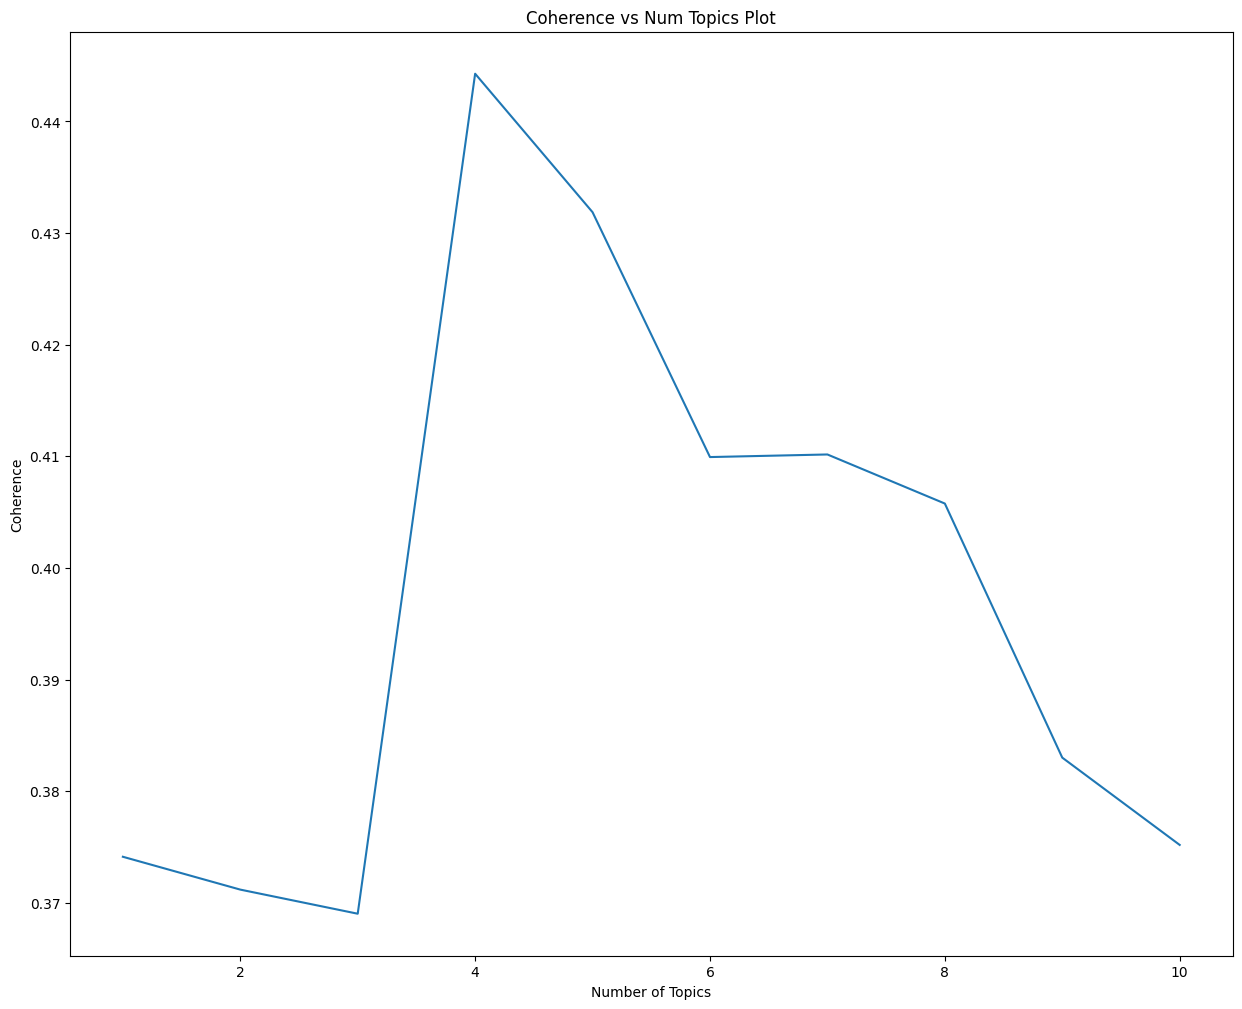

In [ ]:
negative_lda, optimal_topics = get_optimal_lda(negative_gensim_corpus, negative_dictionary, negative_gensim_docs)

In [80]:
print(optimal_topics)

(4, np.float64(0.44427022567816854))


In [ ]:
neg_ldavis = gensimvis.prepare(negative_lda, negative_gensim_corpus, negative_dictionary)
pyLDAvis.display(neg_ldavis)

1/10 Done
2/10 Done
3/10 Done
4/10 Done
5/10 Done
6/10 Done
7/10 Done
8/10 Done
9/10 Done
10/10 Done


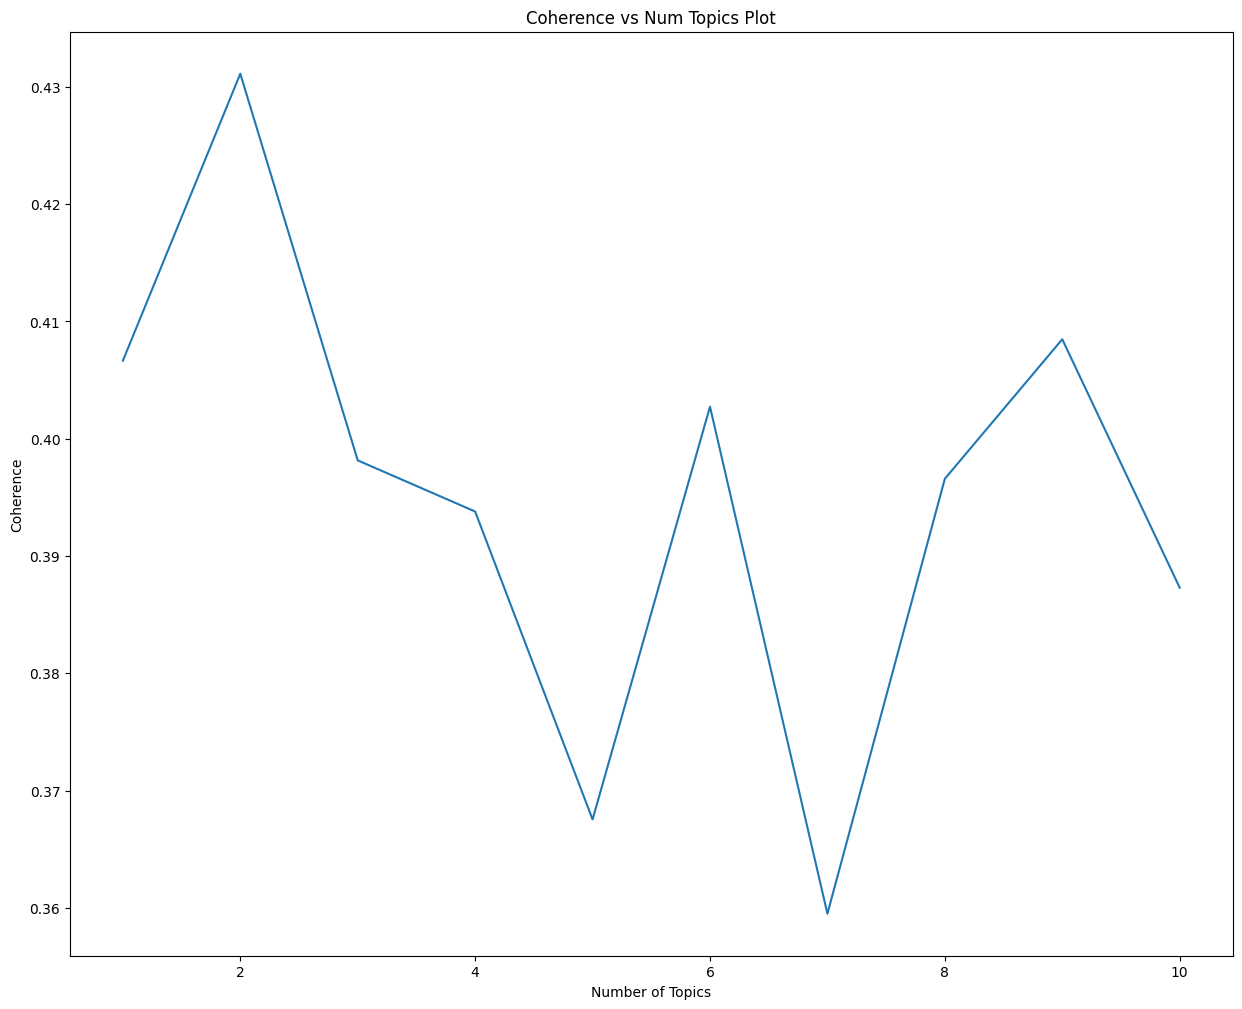

In [94]:
positive_gensim_docs, positive_dictionary, positive_gensim_corpus = get_gensim_reqs(all_positive['Review'].tolist())
positive_lda, _ = get_optimal_lda(positive_gensim_corpus, positive_dictionary, positive_gensim_docs)

In [95]:
pos_ldavis = gensimvis.prepare(positive_lda, positive_gensim_corpus, positive_dictionary)
pyLDAvis.display(pos_ldavis)

# Findings

### Wordcloud
The wordcloud doesn't have much to cover due to the repetitive nature of the words inside the reviews. Majority of them have filler words and nonsensical words that are thrown about only for the fun of the community; however, it is still quite beneficial for us to analyze the words according to their frequency within the user reviews.

Looking at the general overview of negative reviews, we can see that users often complain about microtransactions, matchmaking, and servers respectively. Implying that majority of the user find microtransactions an issue, possibly through its high price, followed by the issues within matchmaking and then servers, which may be connected to the reason why users are complaining about microtransactions (devs might be focusing on microtransactions more on fixing issues in matchmaking and servers). Even after segregating the high hour negative reviews and negative reviews that were marked as helpful, these words still come up within the wordcloud, thus highlighting its significance in player dissatisfaction.

### Kmeans
From the Kmeans model, we can see that majority of the negative reviews are classified as either server issues or bad matchmaking. This means that a lot of the playerbase have complained about getting a bad experience with the servers, possibly high ping, lag, or the constant downtime of the servers; in addition, a large percentage have also raised an issue with matchmaking, stating that alot of the players they get matched with belong to a much higher rank than they are, causing unfair play and skill imbalance within the lobby, with the higher ranked players dominating the low ranked.

In contrast, we see that in the positive reviews, majority of the classified content were about the removal of the origin launcher, which seem to have posed a massive issue to the community. Accompanying this issue, albeit to a smaller magnitude, is the reviews that are categorized as "Unlike Fortnite" and "Emotes and Friends" which both highlight the playerbase's enjoyment to the unique combat movement mechanics that the game has to offer alongside its wide array of user expression within the game.

### LDA
The LDA visuals are a bit harder to interpret compared to KMeans, but we can still piece together information gathered from the various topics. 

Starting with the negative reviews. Let's first start by categorizing each of the topics here. Almost all of the topics contain general words such as "apex", "game", "play", and other such words so we'll ignore those and focus more on the unique ones for that topic. 

Starting with topic 1, we can see words such as "matchmaking", "season", "players", "servers", "money" and other words that seem to be really wide in terms of topic. We can perhaps focus on the words "money", "season", and "players" which seem to imply that the playerbase is getting affected by the recent money involved in each season, perhaps in battlepass or other microtransactions that is frequently implemented in Apex. We can then connect this to other words in the topic such as "matchmaking" and "servers" to possibly hint that players would like it more if the money invested in creating battlepass or microtransactions is instead invested in improving servers and matchmaking issues. With this, we can categorize the 1st topic as "Microtransactions".

Moving on with the 2nd topic, again, we get the same words as before such as "game", "players", "matchmaking", however, the orders are now changed. This time, we also get new words such as "time" and "hours" which may imply that players are complaining about the wait times in matchmaking, which is supported by our previous claim of matchmaking issues for the 1st topic. "Titanfall" also seems pretty high in the list, hinting that players are comparing Apex Legends to Titanfall. With these reasons, I feel that it is acceptable to classify this topic as "Wait Times".

On to the 3rd topic, we get the same words still like "servers", "players", and "money" which means these words are a really frequent topic of complaint in reviews as it is frequently a part of, or at least related to, alot of topics. We do get one new word in the mix that likely defines the topic which is "cheaters". With "players", "servers", "money", and "cheaters", we can assume that this topic pertains to the prevalence of cheaters in many servers despite the frequent game updates. It would seem that players are discontent at how the game continues to update more transactions for the players, yet could not address cheaters in lobbies. As such, we can classify this topic as "Cheaters" as I think it really defines and connects alot of the words in this topic list.

Lastly, on to the 4th topic. Unlike the other topics, this topic doesn't necessarily have any words that stand out from the rest, and like many, it contains other words that have already been mentioned by the other topics, namely "players", "servers", "time", "matchmaking", "money", and "cheaters". Seems like this topic is a mixture of all the other complaints, pointing out the major issues of the game, addressing the numerous accounts of many other reviews. So, since I have no clear assumption to classify this as, we'll categorize it as "Other".

Fortunately, we don't need to rank these as LDA has already ranked it according to the portion of the documents or tokens that the topics are pertaining to. Topic 1 has the highest, with a leading 27.8%, followed by Topic 2's 26.8%, and then Topic 3's 24.6%, and lastly Topic 4's 20.8%. This would imply that a large majority of the reviews mostly contain words that pertain to "Microtransactions" or "Wait Times" along with a bit of "Cheaters".

These assumptions fall in line with the results of our wordclouds earlier, majority of which containing the words "microtransaction", "cheater","server", and "matchmaking" for those in the negative wordcloud outputs.

The positive LDA seems to have grouped the positive reviews into 2 clusters only. Topic 1 and Topic 2 both share seemingly almost identical lists of words. Topic 1, however, has the word "movement" along with the words "battle royale" and "fun" which seem to imply that players find the unique movement of the game unlike any other battle royal they've played, which made it a really unique and fun experience for many players. Topic 2 seems to have generic words in their lists, implying that these percentage of the reviews are the generic reviews that don't really offer much depth into the game's mechanics or intrinsic characteristics, as such, these reviews are likely generic praise given as thanks to the developers of the game.


# Conclusion

From the findings we have, we can generally say that the major issues that most of the players are facing right now is the microtransactions, server issues, and the matchmaking. Players are getting really irked with the amount of microtransactions the game keeps updating and no updates fixing the recurring issues of cheaters, unfair or unbalanced matchmaking, and constant connectivity to the servers. On the other hand, the players seem to be enjoying the distinct movement mechanics of the game, allowing for some of the most dopamine-inducing gameplay that no other battle royale has ever displayed. Nevertheless, in order to regain playerbase, or better yet gain more players, the devs of the game should focus less on microtransactions and more on producing updates that address issues in matchmaking and servers. Some fix that would make matchmaking balanced by adjusting the ranks of all the players that are in the lobby and managing them so that no high-level ranks are grouped in one lobby with only a few low-level ranks. For servers, it's a more delicate matter as the matter solely relies on how the game connects to the server, so, setting up more parallel servers may reduce downtime and improve connectivity, or, having more regional-servers would likely improve server connectivity. Additionally, the devs could introduce more mobility or options in combat for the players to enjoy. They need to emphasize more flexibility and skill expression in combat to match the game's "high skill ceiling" gameplay focused on making outplays and game-changing decisions coupled with great aim.